<a href="https://colab.research.google.com/github/MarceCorreal2/Robots-NT/blob/main/Procesamiento_Datos_Trades_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
# Celda 1 — Importes y configuración

import pandas as pd
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

In [47]:
# Celda 2 — Conectar Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Definir Parámetros de Prueba

### Subtask:
Establecer variables para el nombre del bot, el instrumento y el número de prueba (por ejemplo, 'T001', 'T002') para construir rutas de archivo dinámicamente.

In [48]:
# Celda 3 — Definir Rutas dinamicas
bot_name = 'RB001_MNQ_A' # Se corrige el nombre del bot
test_number = 'T001' # <--- Modifica este valor para diferentes pruebas (ej. 'T002')
instrument = 'MNQ'

print(f"Bot Name: {bot_name}")
print(f"Test Number: {test_number}")
print(f"Instrument: {instrument}")

Bot Name: RB001_MNQ_A
Test Number: T001
Instrument: MNQ


## Generar Rutas de Archivo Dinámicas

### Subtask:
Construir las rutas completas para el archivo CSV de datos crudos, el archivo CSV de datos limpios y el directorio de guardado de gráficas, utilizando los parámetros de prueba definidos.

In [49]:
# Celda 4 - Generación rutas dinámicas

import os

# 1. Define base path for raw data files
raw_data_base_path = '/content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Datos Crudos/'

# 2. Define base path for cleaned data files
cleaned_data_base_path = '/content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Datos Limpios/'

# 3. Define base path for graph output
graph_output_base_path = '/content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Graficas Backtest/'

# 4. Construct full file path for raw CSV data
raw_data_file_path = os.path.join(raw_data_base_path, f'{bot_name}_{test_number}.csv')

# 5. Construct full file path for cleaned CSV data
cleaned_data_file_path = os.path.join(cleaned_data_base_path, f'{bot_name}_{test_number}_limpio.csv')

# 6. Construct full directory path for graphs
graph_output_directory = os.path.join(graph_output_base_path, f'{bot_name}_{test_number}')

# 7. Print all generated paths for verification
print(f"Ruta de archivo de datos crudos: {raw_data_file_path}")
print(f"Ruta de archivo de datos limpios: {cleaned_data_file_path}")
print(f"Directorio de salida de gráficas: {graph_output_directory}")

Ruta de archivo de datos crudos: /content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Datos Crudos/RB001_MNQ_A_T001.csv
Ruta de archivo de datos limpios: /content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Datos Limpios/RB001_MNQ_A_T001_limpio.csv
Directorio de salida de gráficas: /content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Graficas Backtest/RB001_MNQ_A_T001


## Cargar Datos Crudos

### Subtask:
Cargar el archivo CSV de datos crudos utilizando la ruta generada dinámicamente. Este paso reemplazará la selección manual del archivo.

In [50]:
# Celda 5 — Carga de archivo crudo  CSV

df_raw = pd.read_csv(
    raw_data_file_path,
    sep=';',
    dtype={'Entry time': str, 'Exit time': str},
    keep_default_na=False,
    na_values=[]
).copy()

df_raw = df_raw.loc[:, ~df_raw.columns.str.contains('Unnamed')].copy()
df = df_raw.copy()

print(f"DataFrame cargado con {df.shape[0]} filas y {df.shape[1]} columnas.")
display(df.head())

DataFrame cargado con 55 filas y 23 columnas.


,Trade number,Instrument,Account,Strategy,Market pos.,Qty,Entry price,Exit price,Entry time,Exit time,Entry name,Exit name,Profit,Cum. net profit,Commission,Clearing Fee,Exchange Fee,IP Fee,NFA Fee,MAE,MFE,ETD,Bars
0,1,MNQ SEP26,Backtest,RB001,Long,1,"30073,50","30258,75",24/05/2026 6:22:00 p m,25/05/2026 1:00:00 p m,Buy,Exit on session close,"$ 368,60","$ 368,60","$ 1,90","$ 0,00","$ 0,00","$ 0,00","$ 0,00","$ 26,00","$ 434,50","$ 65,90",1119
1,2,MNQ SEP26,Backtest,RB001,Long,1,"30222,00","30113,25",25/05/2026 6:02:00 p m,25/05/2026 8:10:00 p m,Buy,Sell,"-$ 219,40","$ 149,20","$ 1,90","$ 0,00","$ 0,00","$ 0,00","$ 0,00","$ 219,00","$ 49,50","$ 268,90",129
2,3,MNQ SEP26,Backtest,RB001,Long,1,"30120,75","30116,75",25/05/2026 8:14:00 p m,25/05/2026 8:19:00 p m,Buy,Sell,"-$ 9,90","$ 139,30","$ 1,90","$ 0,00","$ 0,00","$ 0,00","$ 0,00","$ 12,00","$ 22,00","$ 31,90",6
3,4,MNQ SEP26,Backtest,RB001,Long,1,"30119,00","30118,00",25/05/2026 8:21:00 p m,25/05/2026 8:25:00 p m,Buy,Sell,"-$ 3,90","$ 135,40","$ 1,90","$ 0,00","$ 0,00","$ 0,00","$ 0,00","$ 9,50","$ 28,00","$ 31,90",5
4,5,MNQ SEP26,Backtest,RB001,Long,1,"30122,50","30116,00",25/05/2026 8:26:00 p m,25/05/2026 8:42:00 p m,Buy,Sell,"-$ 14,90","$ 120,50","$ 1,90","$ 0,00","$ 0,00","$ 0,00","$ 0,00","$ 18,50","$ 59,00","$ 73,90",17


## Limpiar y Preprocesar Datos

### Subtask:
Aplicar las operaciones de limpieza y preprocesamiento de columnas de fecha y numéricas al DataFrame cargado.

In [56]:
import re

df = df_raw.copy()

# Clean and convert date columns
for col in ["Entry time", "Exit time"]:
    # 1. Convert to string and remove known unicode characters and strip leading/trailing spaces
    df[col] = df[col].astype(str).str.replace('\u202a', '', regex=False).str.replace('\u202f', '', regex=False).str.strip()

    # 2. Normalize AM/PM part using regex
    # The regex looks for ' H:MM:SS ' followed by 'a' or 'p', optional spaces, and 'm'.
    # It aims to transform ' 09:30:00 a m' into '09:30:00AM'
    df[col] = df[col].apply(
        lambda x: re.sub(r'(\d{1,2}:\d{2}:\d{2})\s*([ap])\s*m', r'\1\2M', x, flags=re.IGNORECASE)
    )
    df[col] = df[col].str.upper() # Ensure AM/PM are uppercase

# 3. Convert to datetime objects
df["Entry time"] = pd.to_datetime(df["Entry time"], format='%d/%m/%Y %I:%M:%S%p', errors='coerce')
df["Exit time"] = pd.to_datetime(df["Exit time"], format='%d/%m/%Y %I:%M:%S%p', errors='coerce')

# Clean and convert numerical columns
cols_numericas = [
    "Entry price", "Exit price", "Profit", "Cum. net profit",
    "Commission", "Clearing Fee", "Exchange Fee", "IP Fee",
    "NFA Fee", "MAE", "MFE", "ETD"
]
for col in cols_numericas:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(' ', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Date and numerical columns cleaned and converted.")

print("\nVerifying data types after conversion:")
df.info()

print("\nChecking for null values introduced by conversion:")
print(df.isnull().sum())

print("\nDisplaying the first few rows of the cleaned DataFrame:")
display(df.head())

Date and numerical columns cleaned and converted.

Verifying data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Trade number     55 non-null     int64         
 1   Instrument       55 non-null     object        
 2   Account          55 non-null     object        
 3   Strategy         55 non-null     object        
 4   Market pos.      55 non-null     object        
 5   Qty              55 non-null     int64         
 6   Entry price      55 non-null     float64       
 7   Exit price       55 non-null     float64       
 8   Entry time       55 non-null     datetime64[ns]
 9   Exit time        55 non-null     datetime64[ns]
 10  Entry name       55 non-null     object        
 11  Exit name        55 non-null     object        
 12  Profit           55 non-null     float64       
 13  Cum. ne

,Trade number,Instrument,Account,Strategy,Market pos.,Qty,Entry price,Exit price,Entry time,Exit time,Entry name,Exit name,Profit,Cum. net profit,Commission,Clearing Fee,Exchange Fee,IP Fee,NFA Fee,MAE,MFE,ETD,Bars
0,1,MNQ SEP26,Backtest,RB001,Long,1,30073.50,30258.75,2026-05-24 18:22:00,2026-05-25 13:00:00,Buy,Exit on session close,368.6,368.6,1.9,0.0,0.0,0.0,0.0,26.0,434.5,65.9,1119
1,2,MNQ SEP26,Backtest,RB001,Long,1,30222.00,30113.25,2026-05-25 18:02:00,2026-05-25 20:10:00,Buy,Sell,-219.4,149.2,1.9,0.0,0.0,0.0,0.0,219.0,49.5,268.9,129
2,3,MNQ SEP26,Backtest,RB001,Long,1,30120.75,30116.75,2026-05-25 20:14:00,2026-05-25 20:19:00,Buy,Sell,-9.9,139.3,1.9,0.0,0.0,0.0,0.0,12.0,22.0,31.9,6
3,4,MNQ SEP26,Backtest,RB001,Long,1,30119.00,30118.00,2026-05-25 20:21:00,2026-05-25 20:25:00,Buy,Sell,-3.9,135.4,1.9,0.0,0.0,0.0,0.0,9.5,28.0,31.9,5
4,5,MNQ SEP26,Backtest,RB001,Long,1,30122.50,30116.00,2026-05-25 20:26:00,2026-05-25 20:42:00,Buy,Sell,-14.9,120.5,1.9,0.0,0.0,0.0,0.0,18.5,59.0,73.9,17


## Guardar Datos Limpios

### Subtask:
Guardar el DataFrame limpio en un nuevo archivo CSV, utilizando la ruta de datos limpios generada dinámicamente.

In [52]:
# Celda 7 — Guardar Datos Limpios

import os

# Extract the directory path from cleaned_data_file_path
output_dir = os.path.dirname(cleaned_data_file_path)

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

df.to_csv(
    cleaned_data_file_path,
    index=False,
    sep=';'
)

print(f"DataFrame limpio guardado en: {cleaned_data_file_path}")

DataFrame limpio guardado en: /content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Datos Limpios/RB001_MNQ_A_T001_limpio.csv


## Generar y Guardar Gráficas

### Subtask:
Generar las gráficas de 'Equity Curve', 'Equity y Drawdown' y 'Ganancia/Pérdida por Trade' utilizando los datos del DataFrame limpio. Las gráficas se guardarán en los directorios correspondientes, que también se generarán dinámicamente.

Gráfica Equity Curve guardada en: /content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Graficas Backtest/RB001_MNQ_A_T001/Equity_Curve.jpg


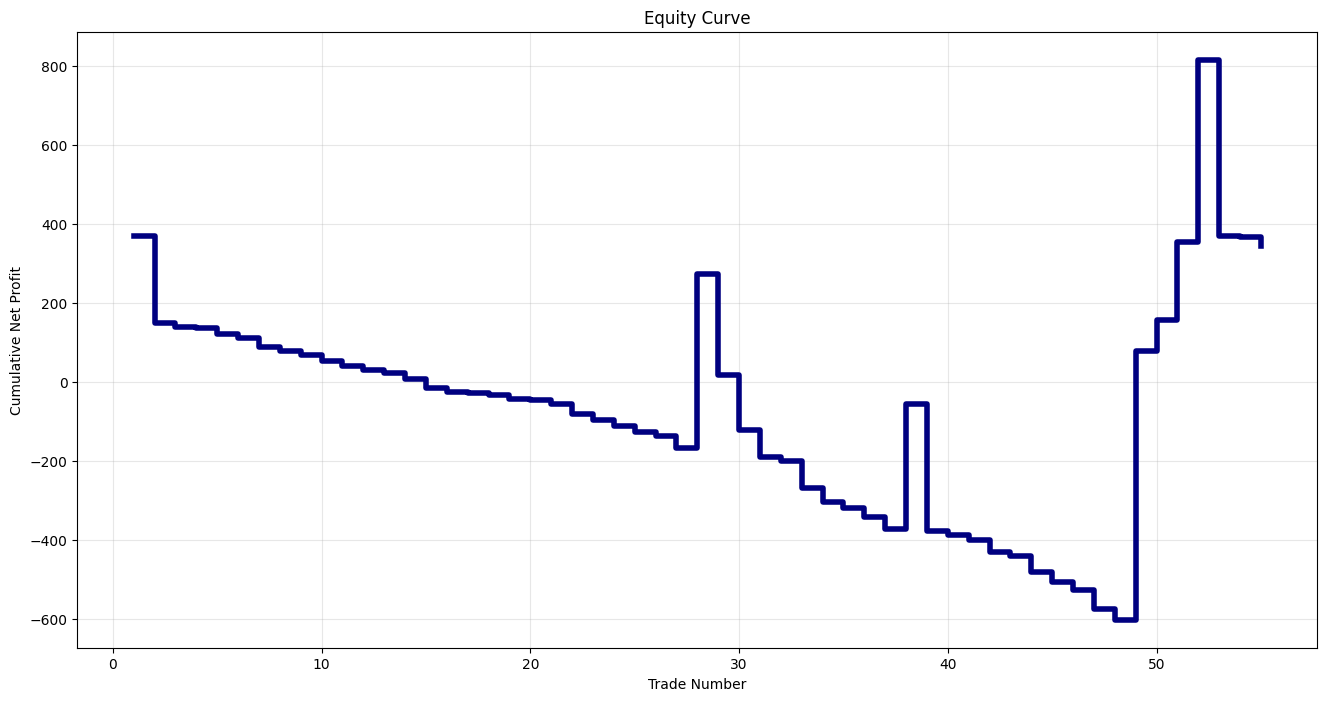

In [53]:
# Celda 8 — Generación de Gráficas (Equity)

import matplotlib.pyplot as plt
import os

os.makedirs(graph_output_directory, exist_ok=True)

plt.figure(figsize=(16,8))

plt.step(
    df['Trade number'],
    df['Cum. net profit'],
    where='post',
    linewidth=4,
    color='navy'
)

plt.title('Equity Curve')
plt.xlabel('Trade Number')
plt.ylabel('Cumulative Net Profit')
plt.grid(True, alpha=0.3)

output_path_equity_curve = os.path.join(graph_output_directory, 'Equity_Curve.jpg')

plt.savefig(output_path_equity_curve, bbox_inches='tight', dpi=300)
print(f'Gráfica Equity Curve guardada en: {output_path_equity_curve}')

plt.show()
plt.close()

Gráfica Equity y Drawdown guardada en: /content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Graficas Backtest/RB001_MNQ_A_T001/Equity_Drawdown.jpg


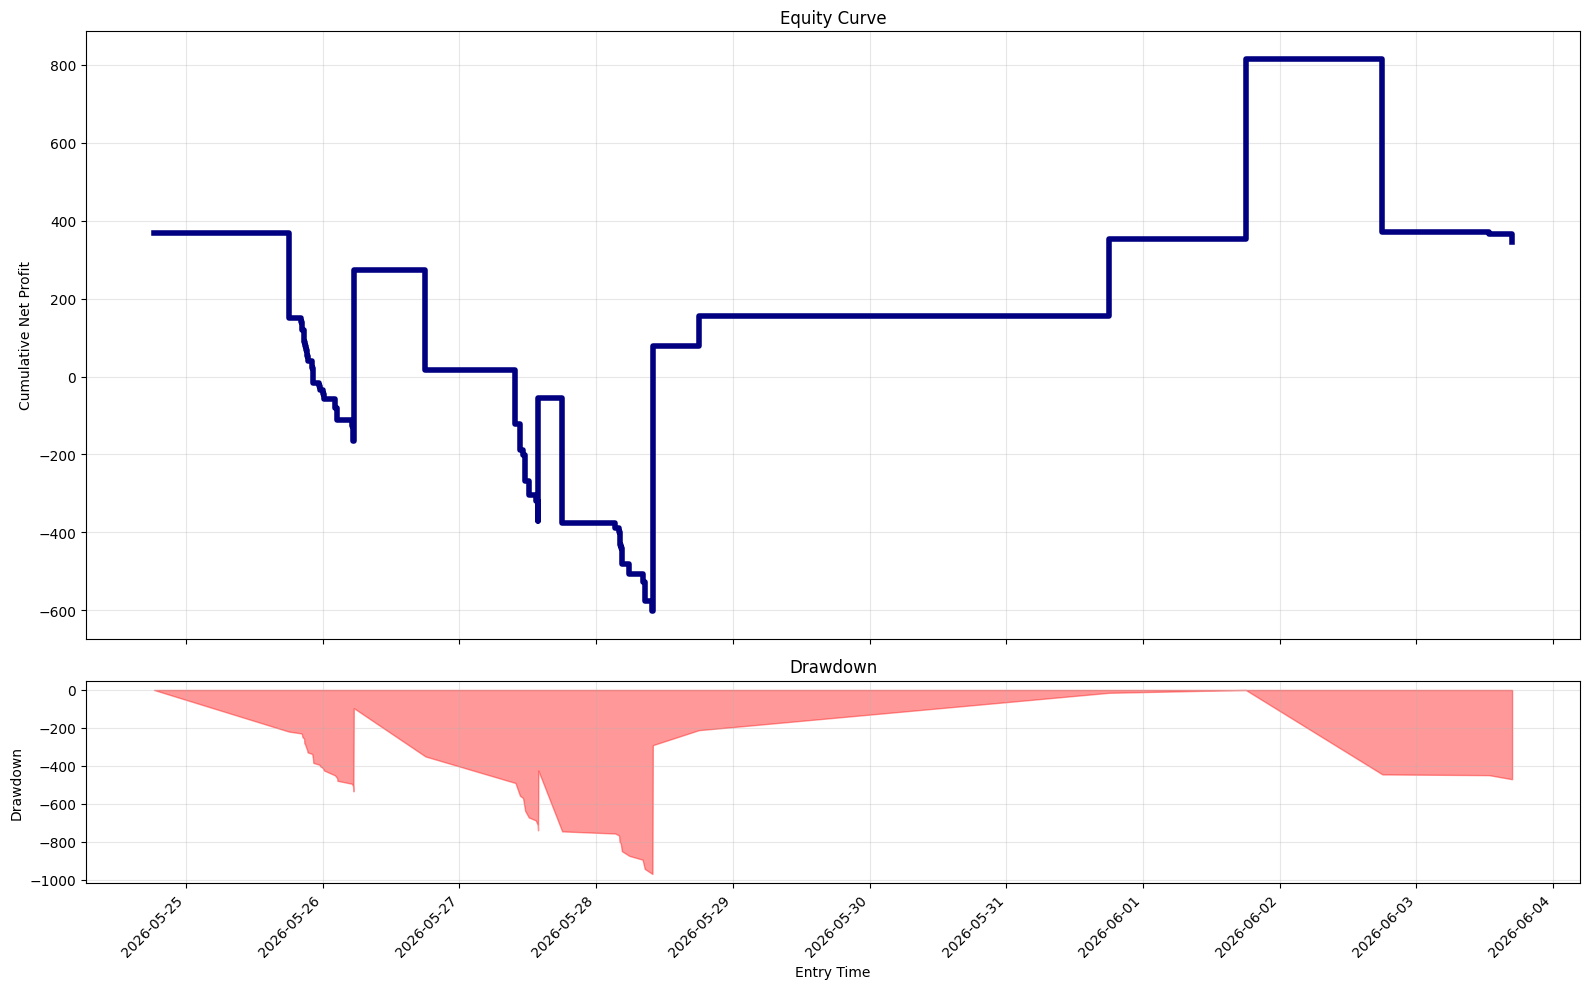

In [54]:
# Celda 9 — Generación de Graficas (Draw Down))

import os
import matplotlib.pyplot as plt

# Calculate HighWaterMark and Drawdown
df['HighWaterMark'] = df['Cum. net profit'].cummax()
df['Drawdown'] = df['Cum. net profit'] - df['HighWaterMark']

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(16,10),
    sharex=True,
    gridspec_kw={'height_ratios':[3,1]}
)

# Plot Equity Curve
ax1.step(
    df['Entry time'],
    df['Cum. net profit'],
    where='post',
    color='navy',
    linewidth=4
)
ax1.set_title('Equity Curve')
ax1.set_ylabel('Cumulative Net Profit')
ax1.grid(alpha=0.3)

# Plot Drawdown
ax2.fill_between(
    df['Entry time'],
    df['Drawdown'],
    0,
    color='red',
    alpha=0.4
)
ax2.set_title('Drawdown')
ax2.set_ylabel('Drawdown')
ax2.grid(alpha=0.3)

# Set common labels and rotate x-axis labels for readability
plt.xlabel('Entry Time')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Construct the full output path for the equity and drawdown graph
output_path_equity_drawdown = os.path.join(graph_output_directory, 'Equity_Drawdown.jpg')

# Create the directory if it doesn't exist
os.makedirs(graph_output_directory, exist_ok=True)

# Save the figure before displaying it
fig.savefig(output_path_equity_drawdown, bbox_inches='tight', dpi=300)
print(f'Gráfica Equity y Drawdown guardada en: {output_path_equity_drawdown}')

plt.show()
plt.close(fig)

Gráfica Ganancia/Pérdida por Trade guardada en: /content/drive/MyDrive/Robots/Mis Bots/Análisis Gráfico/Graficas Backtest/RB001_MNQ_A_T001/Profit_Loss_Per_Trade.jpg


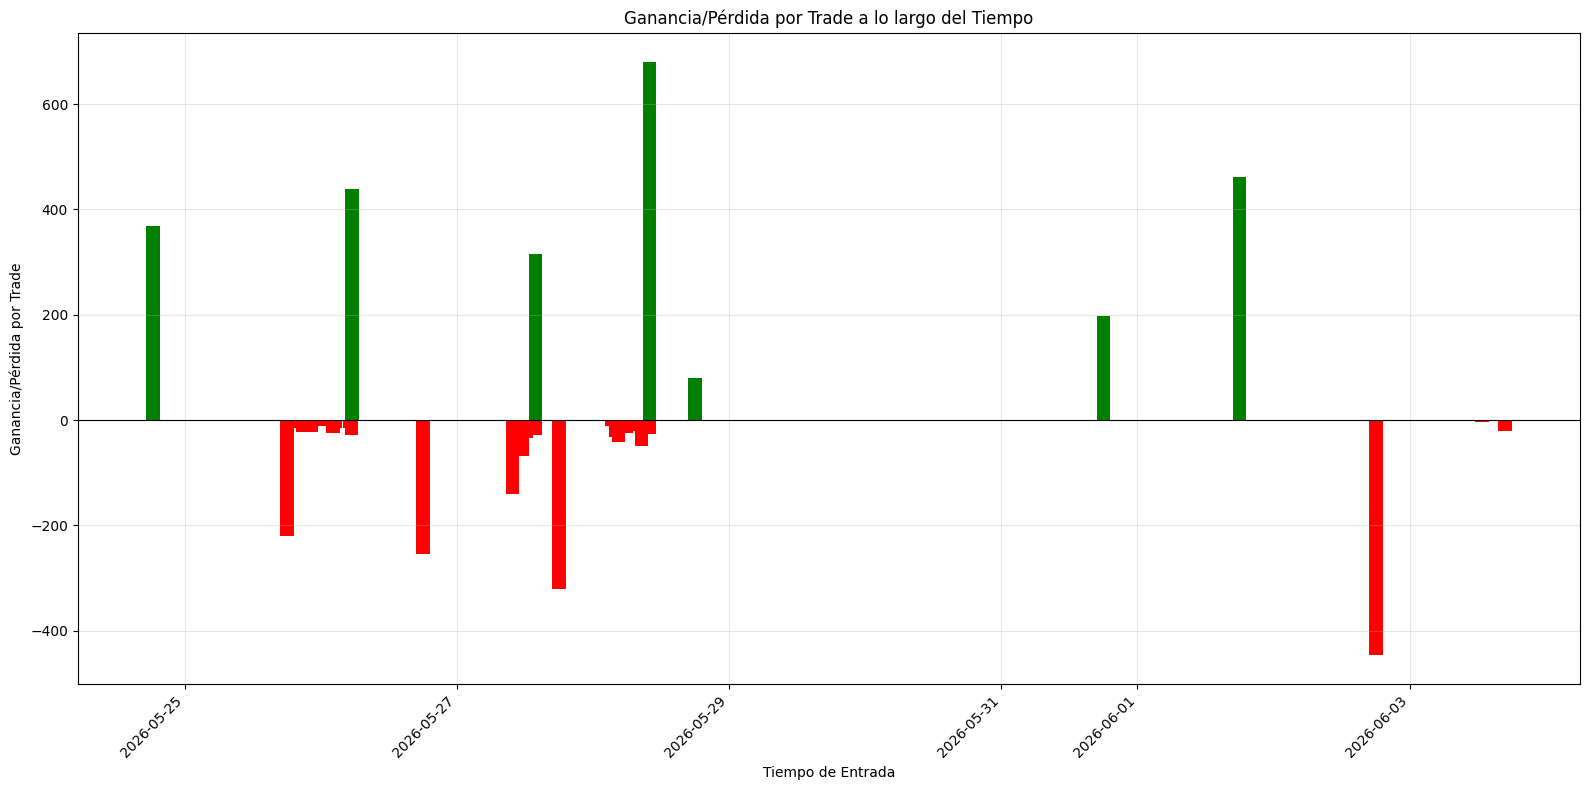

In [55]:
# Celda 10 — Generación de Graficas (Profit-Loos Trades)

import os
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 8))

ax.bar(
    df['Entry time'],
    df['Profit'],
    color=['green' if p > 0 else 'red' for p in df['Profit']], # Green for profit, red for loss
    width=0.1 # Adjust width as needed for better visualization, changed from 0.5 to 0.1
)

ax.set_title('Ganancia/Pérdida por Trade a lo largo del Tiempo')
ax.set_xlabel('Tiempo de Entrada')
ax.set_ylabel('Ganancia/Pérdida por Trade')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.8) # Add a horizontal line at 0 for reference
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()

# Construct the full output path for the profit/loss per trade graph
output_path_profit = os.path.join(graph_output_directory, 'Profit_Loss_Per_Trade.jpg')

# Create the directory if it doesn't exist
os.makedirs(graph_output_directory, exist_ok=True)

# Save the figure before displaying it
fig.savefig(output_path_profit, bbox_inches='tight', dpi=300)
print(f'Gráfica Ganancia/Pérdida por Trade guardada en: {output_path_profit}')

plt.show()
plt.close(fig)